# Data visualization using laptop_price.csv dataset

Write a python code to demonstrate the following using any visualisation library.
1. Central tendency of data (Visual; Numeric)
2. Outlier identification (Visual ; Numeric). Add outliers if the dataset does not have any.
3. Visualizing relationship between 2 numeric variables
4. Visualizing relationship between numeric and nominal variable
5. Visualizing relationship between two nominal variables.

Why these graphs were chosen:
- Histogram + boxplot: together they show both the distribution shape and the central values such as mean, median, and mode.
- Boxplot + IQR rule: this is the standard way to spot outliers visually and confirm them numerically.
- Scatter plot with regression line: it is ideal for two numeric variables because it shows trend and strength of relationship.
- Boxplot by category: it compares a numeric measure across different groups clearly.
- Stacked bar chart of a crosstab: it is more suitable for two nominal variables because it compares category counts across groups clearly.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

df = pd.read_csv('laptop_price.csv', encoding='latin-1')

# Derived numeric columns for easier analysis
# (these are created from existing text columns in the dataset)
df['Weight_kg'] = df['Weight'].astype(str).str.replace('kg', '', regex=False).astype(float)
df['Ram_GB'] = df['Ram'].astype(str).str.replace('GB', '', regex=False).astype(int)

df.head()


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Weight_kg,Ram_GB
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,1.37,8
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,1.34,8
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,1.86,8
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,1.83,16
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,1.37,8


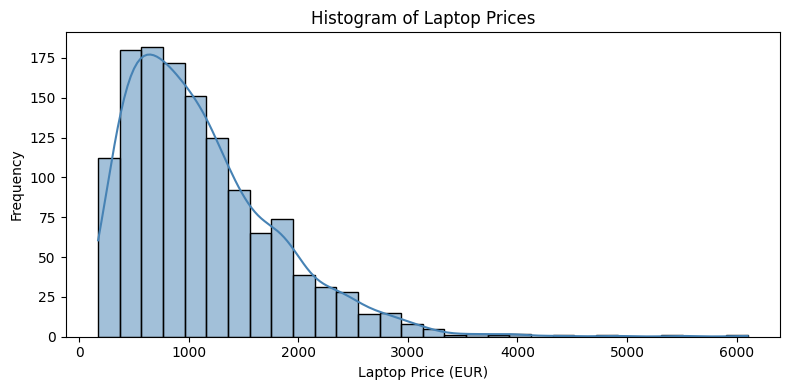

Central tendency summary for Price_euros:
Mean: 1123.69
Median: 977.00
Mode: 1099.00


In [24]:
# 1) Central tendency of data
price = df['Price_euros']
mean_price = price.mean()
median_price = price.median()
mode_price = price.mode().iloc[0]

plt.figure(figsize=(8, 4))
sns.histplot(price, bins=30, kde=True, color='steelblue')
plt.title('Histogram of Laptop Prices')
plt.xlabel('Laptop Price (EUR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Central tendency summary for Price_euros:')
print(f'Mean: {mean_price:.2f}')
print(f'Median: {median_price:.2f}')
print(f'Mode: {mode_price:.2f}')



Outlier detection summary:
Q1: 599.00
Q3: 1487.88
IQR: 888.88
Lower bound: -734.32
Upper bound: 2821.20
Number of outliers: 29


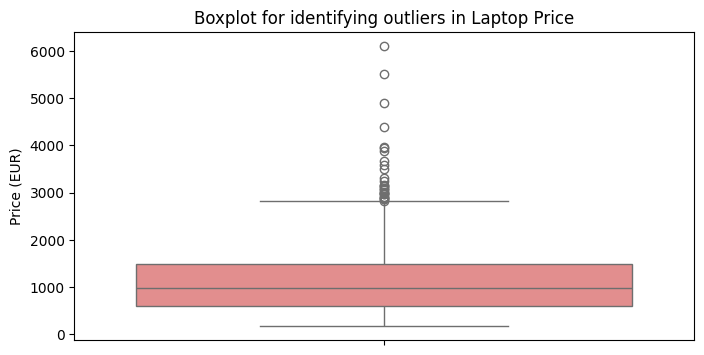


Outlier sample rows:
Company            Product           TypeName  Price_euros  Ram_GB  Weight_kg
  Apple        MacBook Pro          Ultrabook      2858.00      16       1.83
 Lenovo      Thinkpad Yoga 2 in 1 Convertible      2824.00      16       1.42
  Razer          Blade Pro             Gaming      6099.00      32       3.49
   Dell     Precision 7520        Workstation      3055.00      16       2.80
   Asus  ROG G703VI-E5062T             Gaming      3890.00      32       4.70
   Asus Rog G701VIK-BA060T             Gaming      2999.00      16       3.60
   Dell     Precision 7720        Workstation      2884.86      16       3.42
   Asus       ROG Zephyrus             Gaming      2968.00      24       2.24
   Dell       Alienware 17             Gaming      3012.77      16       4.42
 Lenovo       Thinkpad P71           Notebook      2999.00       8       3.40


In [25]:
# 2) Outlier identification (visual + numeric)
Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(price < lower_bound) | (price > upper_bound)].copy()

print('\nOutlier detection summary:')
print(f'Q1: {Q1:.2f}')
print(f'Q3: {Q3:.2f}')
print(f'IQR: {IQR:.2f}')
print(f'Lower bound: {lower_bound:.2f}')
print(f'Upper bound: {upper_bound:.2f}')
print(f'Number of outliers: {len(outliers)}')

plt.figure(figsize=(8, 4))
sns.boxplot(y='Price_euros', data=df, color='lightcoral')
plt.title('Boxplot for identifying outliers in Laptop Price')
plt.ylabel('Price (EUR)')
plt.show()

print('\nOutlier sample rows:')
print(outliers[['Company', 'Product', 'TypeName', 'Price_euros', 'Ram_GB', 'Weight_kg']].head(10).to_string(index=False))



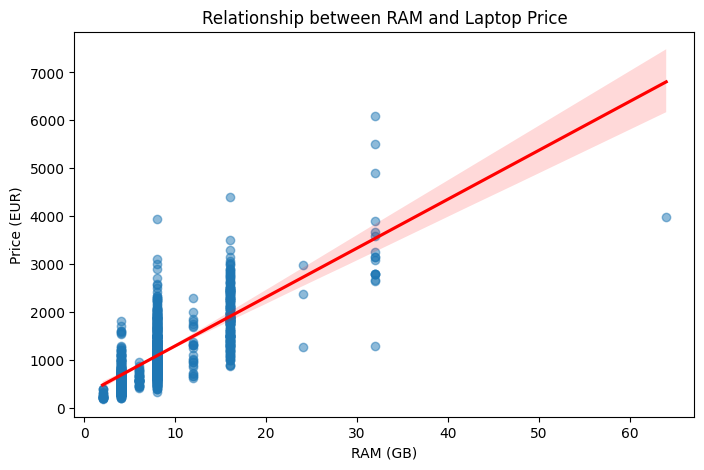


Correlation between RAM and Price: 0.74


In [26]:
# 3) Relationship between two numeric variables
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Ram_GB', y='Price_euros', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Relationship between RAM and Laptop Price')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (EUR)')
plt.show()

corr = df[['Ram_GB', 'Price_euros']].corr().iloc[0, 1]
print(f'\nCorrelation between RAM and Price: {corr:.2f}')



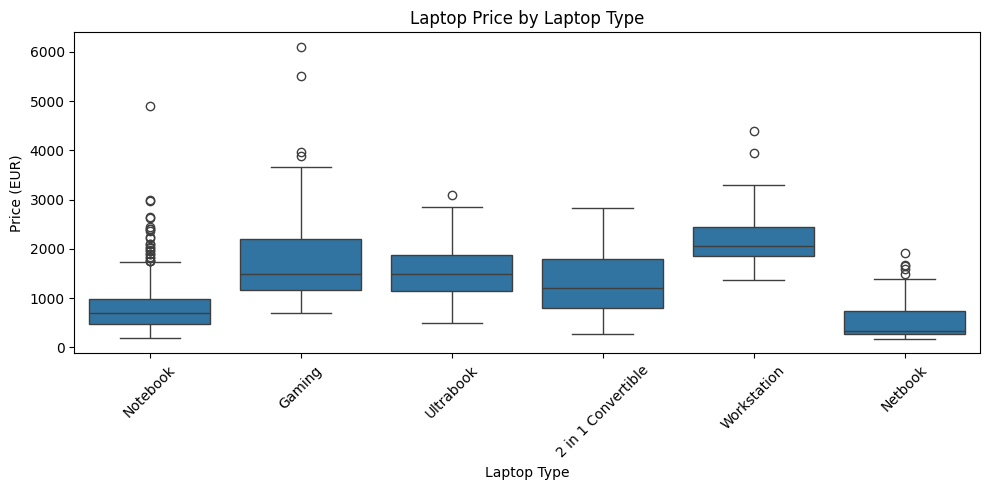

In [27]:
# 4) Relationship between numeric and nominal variable
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='TypeName', y='Price_euros', order=df['TypeName'].value_counts().index)
plt.title('Laptop Price by Laptop Type')
plt.xlabel('Laptop Type')
plt.ylabel('Price (EUR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


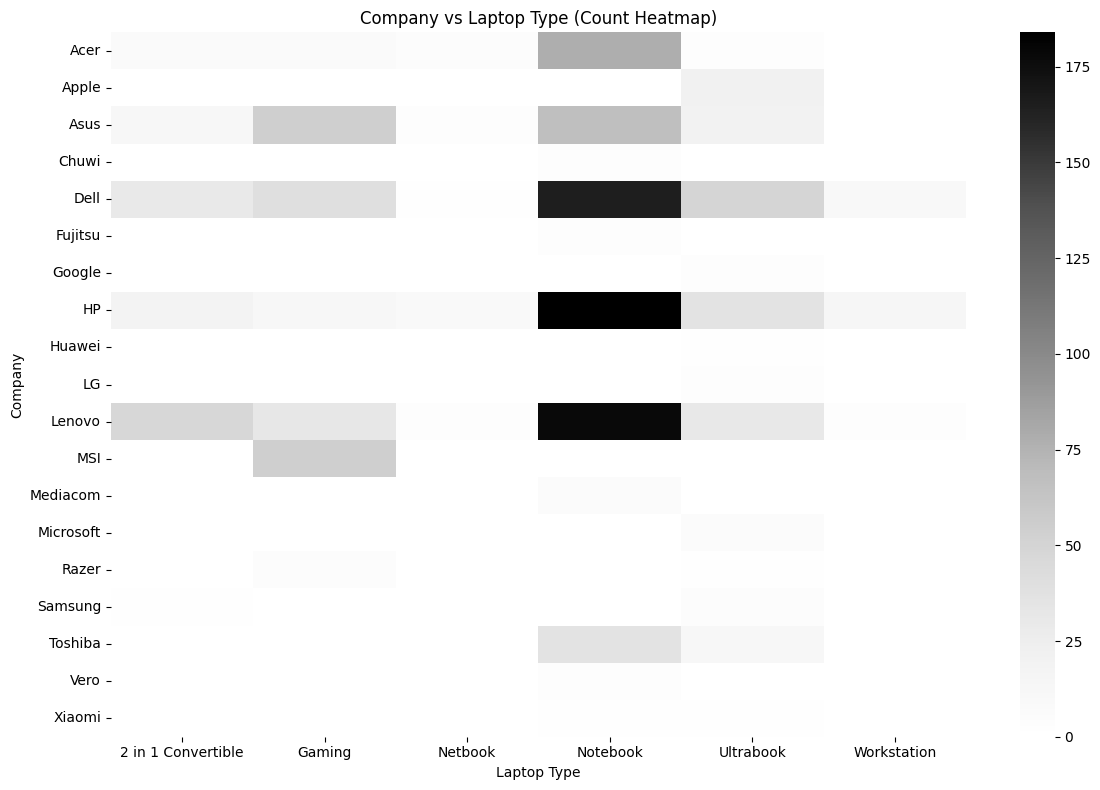

In [28]:

# 5) Relationship between two nominal variables
company_type = pd.crosstab(df['Company'], df['TypeName'])
plt.figure(figsize=(12, 8))
sns.heatmap(company_type, cmap='Greys', annot=False, fmt='d')
plt.title('Company vs Laptop Type (Count Heatmap)')
plt.xlabel('Laptop Type')
plt.ylabel('Company')
plt.tight_layout()
plt.show()
